In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# customizing 'markdown' font style
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedMarkdown{
    color: red !important;
    font-size: 28px !important;
    font-weight: 700 !important;
}
</style>
"""))

In [3]:
# enable all row display
# pd.set_option('display.max_rows', None)

In [4]:
all_dfs = []
sales_data_dir = './output_sales_data'
for file in os.listdir(sales_data_dir):
    # print('CURRENT FILE:', file)
    all_dfs.append(pd.read_csv(os.path.join(sales_data_dir, file)))
df = pd.concat(all_dfs, ignore_index = True)
print('All dfs combined')

All dfs combined


In [5]:
df.head()

,date,company,model,monthly_sales,total_sales
0,Jun-20,Fiat,COMPASS,246.0,246.0
1,Jun-20,Fiat,WRANGLER,10.0,10.0
2,Jun-20,Ford,Figo,174.0,174.0
3,Jun-20,Ford,FREESTYLE,506.0,506.0
4,Jun-20,Ford,Aspire,381.0,381.0


In [6]:
df.describe()

,date,company,model,monthly_sales,total_sales
count,5586,5586,5586,5586,5586
unique,71,16,151,960,960
top,Oct-19,Maruti,COMPASS,1.5K,1.5K
freq,91,1055,71,82,82


In [7]:
df.isna().sum()

date             0
company          0
model            0
monthly_sales    0
total_sales      0
dtype: int64

In [8]:
df.company.unique()

array(['Fiat', 'Ford', 'Honda', 'Hyundai', 'Kia', 'Mahindra', 'Maruti',
       'Morris Garage', 'Nissan', 'Renault', 'Skoda', 'Tata', 'Toyota',
       'Volkswagen', 'Grand Total', 'Citroen'], dtype=object)

In [9]:
for company, company_df in df.groupby('company'):
    print('COMPANY_NAME:', company)
    print(df.loc[df['company'] == company]['model'].unique().tolist(), '\n')

COMPANY_NAME: Citroen
['C3', 'Ë C3', 'C3 Aircross', 'Basalt', 'C5 Aircross'] 

COMPANY_NAME: Fiat
['COMPASS', 'WRANGLER', 'Meridian', 'Linea', 'Grand Cherokee', 'Punto + Evo + Avventura', 'Abarth'] 

COMPANY_NAME: Ford
['Figo', 'FREESTYLE', 'Aspire', 'Ecosport', 'Endeavour', 'Mustang'] 

COMPANY_NAME: Grand Total
['Grand Total'] 

COMPANY_NAME: Honda
['Amaze', 'City', 'WRV', 'Civic', 'CR-V', 'ELEVATE', 'Jazz', 'BR-V'] 

COMPANY_NAME: Hyundai
['Santro', 'Grand i10', 'i20 Elite', 'Xcent/Aura', 'Venue', 'Creta', 'Verna', 'Elantra', 'Tucson', 'KONA', 'EXTER', 'ALCAZAR', 'IONIQ 5'] 

COMPANY_NAME: Kia
['SELTOS', 'CARNIVAL', 'SONET', 'CARENS', 'SYROS', 'EV6', 'EV9'] 

COMPANY_NAME: Mahindra
['Verito', 'KUV 100', 'Bolero', 'XUV 300', 'Scorpio', 'XUV 500', 'XUV 700', 'Thar', 'XUV 400', 'BE6', 'XE 9e', 'Marazzo', 'Alturas G4', 'Xylo', 'TUV 300', 'BE 6', 'XEV 9e', 'NuvoSport'] 

COMPANY_NAME: Maruti
['Alto', 'Eeco', 'S Presso', 'Wagon R', 'IGNIS', 'Ertiga', 'XL6', 'CELERIO', 'Vitara Brezza', 'Sw

In [10]:
df.apply(lambda col: print(col.name, '-', col.dtype))

date - object
company - object
model - object
monthly_sales - object
total_sales - object


date             None
company          None
model            None
monthly_sales    None
total_sales      None
dtype: object

In [11]:
df = df.apply(lambda col: col.str.upper() if col.name in ['company', 'model'] else col)

In [12]:
model_name_corrected = np.array([
    ["Mahindra", "BE6", "BE 6"],
    ["Mahindra", "XE 9e", "XEV 9e"],
    ["Tata", "Safari+Storme", "Safari Storme"],
    ["Toyota", "Innova + Hycross", "Innova"]
])

In [13]:
for car_details in model_name_corrected:
    df.loc[(df['company'] == car_details[0]) & (df['model'] == car_details[1]), 'model'] = str(car_details[2])

In [14]:
df.loc[(df['company'] == 'Fiat') & ((df['model'] == 'WRANGLER') | (df['model'] == 'Meridian') | (df['model'] == 'COMPASS') | (df['model'] == 'Grand Cherokee')), 'company'] = 'Jeep'

In [15]:
# again printing the company names and model names
for company, company_df in df.groupby('company'):
    print('COMPANY_NAME:', company)
    print(df.loc[df['company'] == company]['model'].unique().tolist(), '\n')

COMPANY_NAME: CITROEN
['C3', 'Ë C3', 'C3 AIRCROSS', 'BASALT', 'C5 AIRCROSS'] 

COMPANY_NAME: FIAT
['COMPASS', 'WRANGLER', 'MERIDIAN', 'LINEA', 'GRAND CHEROKEE', 'PUNTO + EVO + AVVENTURA', 'ABARTH'] 

COMPANY_NAME: FORD
['FIGO', 'FREESTYLE', 'ASPIRE', 'ECOSPORT', 'ENDEAVOUR', 'MUSTANG'] 

COMPANY_NAME: GRAND TOTAL
['GRAND TOTAL'] 

COMPANY_NAME: HONDA
['AMAZE', 'CITY', 'WRV', 'CIVIC', 'CR-V', 'ELEVATE', 'JAZZ', 'BR-V'] 

COMPANY_NAME: HYUNDAI
['SANTRO', 'GRAND I10', 'I20 ELITE', 'XCENT/AURA', 'VENUE', 'CRETA', 'VERNA', 'ELANTRA', 'TUCSON', 'KONA', 'EXTER', 'ALCAZAR', 'IONIQ 5'] 

COMPANY_NAME: KIA
['SELTOS', 'CARNIVAL', 'SONET', 'CARENS', 'SYROS', 'EV6', 'EV9'] 

COMPANY_NAME: MAHINDRA
['VERITO', 'KUV 100', 'BOLERO', 'XUV 300', 'SCORPIO', 'XUV 500', 'XUV 700', 'THAR', 'XUV 400', 'BE6', 'XE 9E', 'MARAZZO', 'ALTURAS G4', 'XYLO', 'TUV 300', 'BE 6', 'XEV 9E', 'NUVOSPORT'] 

COMPANY_NAME: MARUTI
['ALTO', 'EECO', 'S PRESSO', 'WAGON R', 'IGNIS', 'ERTIGA', 'XL6', 'CELERIO', 'VITARA BREZZA', 'SW

In [16]:
target_vehicles = {
    "CITROEN": ['C3', 'Ë C3', 'C3 Aircross', 'Basalt', 'C5 Aircross'], 
    "FORD": ['ECOSPORT', 'ENDEAVOUR'],
    "HONDA": ['WRV', 'CR-V', 'ELEVATE', 'BR-V'],
    "HYUNDAI": ['VENUE', 'CRETA', 'TUCSON', 'KONA', 'EXTER', 'ALCAZAR', 'IONIQ 5'],
    "JEEP": ['COMPASS', 'WRANGLER', 'MERIDIAN', 'GRAND CHEROKEE'],
    "KIA": ['SELTOS', 'CARNIVAL', 'SONET', 'CARENS', 'SYROS', 'EV6', 'EV9'],
    "MAHINDRA" : ['KUV 100', 'BOLERO', 'XUV 300', 'SCORPIO', 'XUV 500', 'XUV 700', 'THAR', 'XUV 400', 'BE 6', 'XEV 9E', 'MARAZZO', 'ALTURAS G4', 'XYLO', 'TUV 300', 'NUVOSPORT'],
    "MARUTI" : ['S PRESSO', 'ERTIGA', 'XL6','VITARA BREZZA', 'GYPSY', 'FRONX', 'JIMNY', 'INVICTO', 'GRAND VITARA', 'S-CROSS'],
    "MORRIS GARAGE" : ['HECTOR', 'ZS EV', 'GLOSTER', 'ASTOR'],
    "NISSAN" : ['GO+', 'KICKS', 'MAGNITE', 'TERRANO', 'X-TRAIL'],
    "RENAULT" : ['TRIBER', 'DUSTER', 'KIGER', 'LODGY', 'CAPTUR'],
    "SKODA" : ['KAROQ', 'KYLAQ', 'KUSHAQ', 'KODIAQ'], 
    "TATA" : ['NEXON', 'HARRIER', 'PUNCH', 'SAFARI', 'CURVV', 'SAFARI STORME', 'HEXA'],
    "TOYOTA" : ['INNOVA', 'FORTUNER', 'TAISOR', 'RUMION', 'HYRYDER', 'PRADO', 'LANDCRUISER', 'URBAN CRUISER'],
    "VOLKSWAGEN" : ['TAIGUN', 'TIGUAN', 'T-ROC']
}

In [17]:
# new empty df with same structure
dftv = pd.DataFrame(columns = df.columns.tolist())

In [18]:
for company in target_vehicles.keys():
    for model in target_vehicles[company]:
        dftv = pd.concat([dftv, df.loc[(df['company'] == company) & (df['model'] == model)]], ignore_index = True)    

In [19]:
# dropping 'monthly_sales' column
dftv.drop('monthly_sales', axis=1, inplace=True)

In [20]:
dftv.rename(columns={'total_sales': 'sales'}, inplace=True)

In [21]:
dftv.describe()

,date,company,model,sales
count,2938,2938,2938,2938
unique,71,14,81,697
top,Mar-25,MAHINDRA,VITARA BREZZA,2.1K
freq,55,541,71,55


In [22]:
dftv.head()

,date,company,model,sales
0,Jan-25,CITROEN,C3,242.0
1,Mar-25,CITROEN,C3,120.0
2,Mar-24,CITROEN,C3,265.0
3,Jul-24,CITROEN,C3,90.0
4,Jan-24,CITROEN,C3,234.0


In [23]:
dftv.to_csv('target_vehicles.csv')

In [24]:
# checking the data types of each row
dftv.apply(lambda col: print(col.name, '-', col.dtype))

date - object
company - object
model - object
sales - object


date       None
company    None
model      None
sales      None
dtype: object

In [25]:
dftv['sales_temp'] = dftv['sales'][dftv['sales'].str.contains('K', na = False)]

In [26]:
# dftv['temp_sales'] = dftv[dftv['sales'].str.contains('K', regex = False)]
dftv.describe()

,date,company,model,sales,sales_temp
count,2938,2938,2938,2938,1806
unique,71,14,81,697,174
top,Mar-25,MAHINDRA,VITARA BREZZA,2.1K,2.1K
freq,55,541,71,55,55


In [27]:
dftv['sales_temp'].unique()

array([nan, '1.1K', '1.2K', '1.4K', '3.1K', '3.5K', '3.3K', '3.9K',
       '2.4K', '2.2K', '5.5K', '1.6K', '2.3K', '2.8K', '3.8K', '3.2K',
       '4.3K', '3.7K', '1.7K', '4.6K', '3.6K', '2.9K', '1.0K', '1.3K',
       '1.5K', '1.8K', '2.5K', '4.8K', '2.1K', '5.0K', '4.4K', '2.0K',
       '5.7K', '4.1K', '11.1K', '9.6K', '10.4K', '8.8K', '11.8K', '4.9K',
       '11.6K', '10.3K', '10.7K', '10.1K', '10.0K', '9.2K', '12.0K',
       '11.4K', '6.7K', '6.1K', '8.2K', '9.9K', '9.7K', '9.8K', '9.3K',
       '7.9K', '11.2K', '10.9K', '8.6K', '8.4K', '10.2K', '9.5K', '12.3K',
       '9.1K', '8.9K', '10.6K', '8.3K', '7.0K', '12.2K', '11.0K', '8.5K',
       '7.2K', '18.5K', '6.6K', '18.1K', '16.5K', '17.4K', '13.2K',
       '14.4K', '13.8K', '15.0K', '14.1K', '14.0K', '10.5K', '12.6K',
       '6.9K', '11.5K', '13.0K', '16.3K', '15.5K', '13.3K', '12.5K',
       '12.4K', '17.5K', '7.3K', '12.7K', '14.2K', '11.9K', '7.6K',
       '13.1K', '15.4K', '15.3K', '6.5K', '15.9K', '14.7K', '6.0K',
       '16.8

In [28]:
dftv.head()

,date,company,model,sales,sales_temp
0,Jan-25,CITROEN,C3,242.0,NaN
1,Mar-25,CITROEN,C3,120.0,NaN
2,Mar-24,CITROEN,C3,265.0,NaN
3,Jul-24,CITROEN,C3,90.0,NaN
4,Jan-24,CITROEN,C3,234.0,NaN


In [29]:
dftv['sales_temp'] = dftv['sales_temp'].str.replace('K', '', regex=False)

In [30]:
dftv['sales_temp'] = dftv['sales_temp'].astype('float')

In [31]:
dftv['sales_temp'] = dftv['sales_temp'] * 1000

In [32]:
dftv.loc[(dftv['sales_temp'].notna()), 'sales'] = dftv['sales_temp']

In [33]:
dftv['sales'].str.contains('K', regex = False).unique()

array([False, nan], dtype=object)

In [34]:
# dftv.to_csv('temp_dataset.csv')

In [35]:
dftv.isna().sum()

date             0
company          0
model            0
sales            0
sales_temp    1132
dtype: int64

In [36]:
dftv['sales'] = dftv['sales'].astype(float)

In [37]:
dftv.apply(lambda col: print(col.name, '-', col.dtype))

date - object
company - object
model - object
sales - float64
sales_temp - float64


date          None
company       None
model         None
sales         None
sales_temp    None
dtype: object

In [38]:
dftv.groupby('company')['sales'].sum()

company
CITROEN            19304.0
FORD               93184.0
HONDA              91613.0
HYUNDAI          1741056.0
KIA              1198166.0
MAHINDRA         1921939.0
MARUTI           2782075.0
MORRIS GARAGE     225738.0
NISSAN            144280.0
RENAULT           279794.0
SKODA             106025.0
TATA             1548794.0
TOYOTA            399997.0
VOLKSWAGEN         87385.0
Name: sales, dtype: float64

In [39]:
# converting 'date' column data type into 'datetime64[ns]' 
# pd.to_datetime(df['date'], format='%m-%Y')
dftv['date'] = pd.to_datetime(dftv['date'], format='%b-%y')

In [40]:
dftv = dftv.sort_values(by='date', ascending=True)

In [41]:
dftv.head()

,date,company,model,sales,sales_temp
2268,2019-04-01,RENAULT,LODGY,46.0,NaN
959,2019-04-01,MAHINDRA,XUV 300,4200.0,4200.0
2700,2019-04-01,TOYOTA,FORTUNER,1500.0,1500.0
2382,2019-04-01,SKODA,KODIAQ,75.0,NaN
2106,2019-04-01,NISSAN,TERRANO,60.0,NaN


In [42]:
dftv = dftv.loc[(dftv['date'] >= '2021-04-01') & (dftv['date'] <= '2025-03-31')]

In [43]:
dftv.head()

,date,company,model,sales,sales_temp
1147,2021-04-01,MAHINDRA,THAR,3400.0,3400.0
594,2021-04-01,KIA,SELTOS,8100.0,8100.0
313,2021-04-01,HYUNDAI,CRETA,12500.0,12500.0
866,2021-04-01,MAHINDRA,BOLERO,6200.0,6200.0
135,2021-04-01,HONDA,WRV,1200.0,1200.0


In [44]:
dftv.tail()

,date,company,model,sales,sales_temp
216,2025-03-01,HYUNDAI,VENUE,10400.0,10400.0
1123,2025-03-01,MAHINDRA,THAR,8900.0,8900.0
568,2025-03-01,KIA,SELTOS,6500.0,6500.0
1211,2025-03-01,MAHINDRA,MARAZZO,10.0,NaN
1209,2025-03-01,MAHINDRA,XEV 9E,2100.0,2100.0


/var/folders/_7/8mmqgn7s4bjc8l8cr6llqzq80000gn/T/ipykernel_1211/4190643900.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  sales_year = dftv.groupby(pd.Grouper(key='date', freq='Y'))['sales'].sum().sort_index(ascending = False)


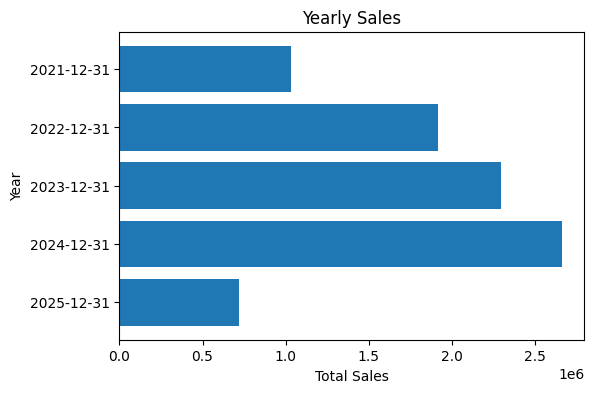

In [45]:
sales_year = dftv.groupby(pd.Grouper(key='date', freq='Y'))['sales'].sum().sort_index(ascending = False)
plt.figure(figsize=(6, 4))
plt.barh(sales_year.index.astype(str), sales_year.values)
plt.xlabel('Total Sales')
plt.ylabel('Year')
plt.title('Yearly Sales')
# plt.tight_layout()
plt.show()

In [46]:
top_20_models_sales = dftv.groupby('model')['sales'].sum().nlargest(20)

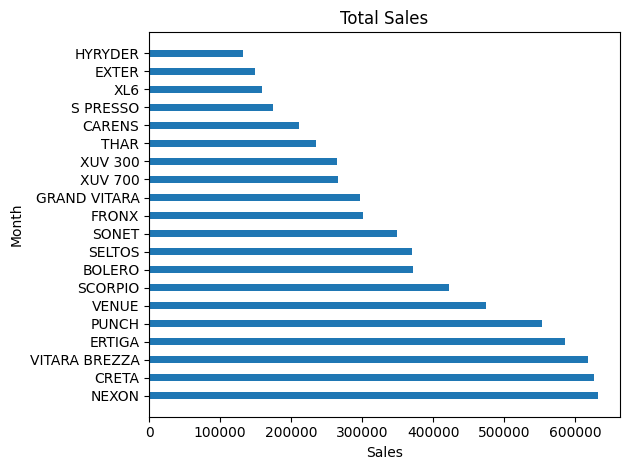

In [47]:
plt.figure()
plt.barh(top_20_models_sales.index.astype(str), top_20_models_sales.values, height = 0.4)
plt.xlabel('Sales')
plt.ylabel('Month')
plt.title('Total Sales')
plt.tight_layout()
plt.show()

Processing Features Dataframe

In [48]:
all_car_features = []
all_car_prices = []
features_data_dir = './output_cardekho_top_20_models'
for file in os.listdir(features_data_dir):
    if file.endswith("features.csv"):
        # print('CURRENT FILE:', file)
        all_car_features.append(pd.read_csv(os.path.join(features_data_dir, file)))
    elif file.endswith("price.csv"):
        current_car_price = pd.read_csv(os.path.join(features_data_dir, file))
        car_details = file.split('-')
        current_car_price['company'] = car_details[0] # adding the company column to the price list
        current_car_price['model'] = car_details[1] # adding the model column to the price list
        current_car_price['variant'] = car_details[2][:-10] # adding the variant column to the price list
        all_car_prices.append(current_car_price)
features = pd.concat(all_car_features, ignore_index = True)
prices = pd.concat(all_car_prices, ignore_index = True)
print('All car features and prices combined')

All car features and prices combined


In [49]:
# saving the combined list of features into a file
features.to_csv(os.path.join(features_data_dir, 'all_car_features.csv'))
# saving the combined list of prices into a file
prices.to_csv(os.path.join(features_data_dir, 'all_car_prices.csv'))

In [50]:
features_data_dir = './output_cardekho_top_20_models'
features = pd.read_csv(os.path.join(features_data_dir, 'all_car_features.csv'))
prices = pd.read_csv(os.path.join(features_data_dir, 'all_car_prices.csv'))

In [51]:
features.describe()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0
count,197088.000000,131392.000000,65696.000000
mean,98543.500000,65695.500000,32847.500000
std,56894.549264,37929.747622,18964.945979
min,0.000000,0.000000,0.000000
25%,49271.750000,32847.750000,16423.750000
50%,98543.500000,65695.500000,32847.500000
75%,147815.250000,98543.250000,49271.250000
max,197087.000000,131391.000000,65695.000000


In [52]:
prices.describe()

,Unnamed: 0
count,5000.000000
mean,2499.500000
std,1443.520003
min,0.000000
25%,1249.750000
50%,2499.500000
75%,3749.250000
max,4999.000000


In [53]:
features.head()

,Unnamed: 0.2,company,model,variant,feature_name,feature_details,Unnamed: 0.1,Unnamed: 0
0,0,mahindra,xuv300,XUV300 W4 Diesel BSVI,Engine Type,1.5L Turbo Diesel with CRDi,NaN,NaN
1,1,mahindra,xuv300,XUV300 W4 Diesel BSVI,Displacement,1497 cc,NaN,NaN
2,2,mahindra,xuv300,XUV300 W4 Diesel BSVI,Max Power,115.05bhp@3750rpm,NaN,NaN
3,3,mahindra,xuv300,XUV300 W4 Diesel BSVI,Max Torque,300Nm@1500-2500rpm,NaN,NaN
4,4,mahindra,xuv300,XUV300 W4 Diesel BSVI,No. of Cylinders,4,NaN,NaN


In [54]:
prices.head()

,Unnamed: 0,Ex-Showroom/ On-Road,Price,company,model,variant
0,0,Ex-Showroom Price,"Rs.9,14,890",TATA,NEXON,Nexon Smart Plus CNG
1,1,Bangalore,Rs.11.15 Lakh*,TATA,NEXON,Nexon Smart Plus CNG
2,2,Mumbai,Rs.10.25 Lakh*,TATA,NEXON,Nexon Smart Plus CNG
3,3,Pune,Rs.10.53 Lakh*,TATA,NEXON,Nexon Smart Plus CNG
4,4,Hyderabad,Rs.10.91 Lakh*,TATA,NEXON,Nexon Smart Plus CNG


In [55]:
features = features[['company', 'model', 'variant', 'feature_name', 'feature_details']]

In [56]:
# filtering out the top 20 models by sales
features.loc[(features['model'].isin(top_20_models_sales.index.tolist()))]

,company,model,variant,feature_name,feature_details
120,HYUNDAI,CRETA,Creta SX Tech,Engine Type,1.5L MPi
121,HYUNDAI,CRETA,Creta SX Tech,Displacement,1497 cc
122,HYUNDAI,CRETA,Creta SX Tech,Max Power,113.18bhp@6300rpm
123,HYUNDAI,CRETA,Creta SX Tech,Max Torque,143.8Nm@4500rpm
124,HYUNDAI,CRETA,Creta SX Tech,No. of Cylinders,4
...,...,...,...,...,...
197083,KIA,SELTOS,Seltos HTE Opt iVT,Apple CarPlay,YES
197084,KIA,SELTOS,Seltos HTE Opt iVT,No. of Speakers,6
197085,KIA,SELTOS,Seltos HTE Opt iVT,Usb Ports,YES
197086,KIA,SELTOS,Seltos HTE Opt iVT,Additional Features,Wireless Android Auto/Apple CarPlay


In [57]:
features.describe()

,company,model,variant,feature_name,feature_details
count,197088,197088,197088,197088,196965
unique,8,22,500,261,773
top,HYUNDAI,CRETA,XUV300 W6 Diesel Sunroof BSVI,Additional Features,YES
freq,52755,29118,600,2730,88350


In [58]:
features.model.unique()

array(['xuv300', 'CRETA', 'NEXON', 'BOLERO', 'GRAND VITARA', 'SELTOS',
       'VENUE', 'PUNCH', 'brezza', 'S PRESSO', 'EXTER', 'CARENS',
       'xuv700', 'VITARA BREZZA', 'XL6', 'HYRYDER', 'SONET', 'FRONX',
       'SCORPIO', 'xuv-3xo', 'THAR', 'ERTIGA'], dtype=object)

Processing 'prices' DataFrame

In [59]:
# trimming 'Rs.' from the beginning of each cell in the row 'Price'
prices['Price'] = prices['Price'].str[3:]

In [60]:
len(prices['model'].unique())

22

In [61]:
prices['Price_temp'] = prices['Price']

In [62]:
# '10.5 Lakh*' -> '10.5' -> 'Lakh*' removed has been removed from the end
# '10,50,000' -> '1050000' -> ',' removed
prices['Price_temp'] = prices.apply(lambda row: row['Price'][:-5] if row['Price'][-5:] == "Lakh*" else row['Price'].replace(',', ''), axis = 1)

In [63]:
# converting the data type of Price_temp column from string to float
prices['Price_temp'] = prices['Price_temp'].astype('float')

In [64]:
# converting format for 'Ex-Showroom Price' rows
# 950000 -> 9.5
prices['Price_temp'] = prices.apply(lambda row: row['Price_temp'] / 100000  if row['Price'][-5:] != "Lakh*" else row['Price_temp'], axis = 1)

In [65]:
# droping the initial 'Price' column
prices = prices.drop(['Price'], axis = 1)

In [66]:
# renaming 'Price_temp' to 'price'
prices = prices.rename(columns={'Price_temp': 'price'})

In [67]:
prices.head()

,Unnamed: 0,Ex-Showroom/ On-Road,company,model,variant,price
0,0,Ex-Showroom Price,TATA,NEXON,Nexon Smart Plus CNG,9.1489
1,1,Bangalore,TATA,NEXON,Nexon Smart Plus CNG,11.1500
2,2,Mumbai,TATA,NEXON,Nexon Smart Plus CNG,10.2500
3,3,Pune,TATA,NEXON,Nexon Smart Plus CNG,10.5300
4,4,Hyderabad,TATA,NEXON,Nexon Smart Plus CNG,10.9100


In [68]:
(prices['model'].unique())

array(['NEXON', 'xuv300', 'GRAND VITARA', 'SONET', 'BOLERO', 'CRETA',
       'SELTOS', 'xuv_3xo', 'xuv700', 'brezza', 'FRONX', 'HYRYDER', 'XL6',
       'PUNCH', 'EXTER', 'S PRESSO', 'VENUE', 'VITARA BREZZA', 'CARENS',
       'SCORPIO', 'ERTIGA', 'THAR'], dtype=object)

In [69]:
prices['model'].unique()

array(['NEXON', 'xuv300', 'GRAND VITARA', 'SONET', 'BOLERO', 'CRETA',
       'SELTOS', 'xuv_3xo', 'xuv700', 'brezza', 'FRONX', 'HYRYDER', 'XL6',
       'PUNCH', 'EXTER', 'S PRESSO', 'VENUE', 'VITARA BREZZA', 'CARENS',
       'SCORPIO', 'ERTIGA', 'THAR'], dtype=object)

Pivot 'Features' Dataframes

In [70]:
features_pivot = features.pivot_table(
    index = ['company', 'model', 'variant'],
    columns = 'feature_name',
    values = 'feature_details',
    aggfunc='first'
)
features_pivot = features_pivot.reset_index()
features_pivot.to_csv('features_pivot.csv')
features_pivot

feature_name,company,model,variant,0-100Kmph (Tested),0-100kmph,360 View Camera,3rd Gear (30-80kmph),4th Gear (40-100kmph),Acceleration,Accessory Power Outlet,...,Ventilated Seats,Voice Commands,Voice assisted sunroof,Wheel Base,Wheel Covers,Wheel Size,Wi-Fi Connectivity,Width,Wireless Phone Charging,Xenon Headlamps
0,HYUNDAI,CRETA,Creta E,NaN,NaN,NO,NaN,NaN,NaN,YES,...,NO,NO,NO,2610 mm,YES,16 Inch,NaN,1790 mm,NO,NaN
1,HYUNDAI,CRETA,Creta E Diesel,NaN,NaN,NO,NaN,NaN,NaN,YES,...,NO,NO,NO,2610 mm,YES,16 Inch,NaN,1790 mm,NO,NaN
2,HYUNDAI,CRETA,Creta EX,NaN,NaN,NO,NaN,NaN,NaN,YES,...,NO,YES,NO,2610 mm,YES,16 Inch,NaN,1790 mm,NO,NaN
3,HYUNDAI,CRETA,Creta EX (O),NaN,NaN,NO,NaN,NaN,NaN,YES,...,NO,YES,NO,2610 mm,YES,16 Inch,NaN,1790 mm,NO,NaN
4,HYUNDAI,CRETA,Creta EX (O) Diesel,NaN,NaN,NO,NaN,NaN,NaN,YES,...,NO,YES,NO,2610 mm,YES,16 Inch,NaN,1790 mm,NO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,maruti,brezza,Brezza Zxi DT,NaN,NaN,NO,NaN,NaN,NaN,YES,...,NaN,NaN,NaN,2500 mm,NO,NaN,NaN,1790 mm,NO,NaN
496,maruti,brezza,Brezza Zxi Plus,NaN,NaN,YES,NaN,NaN,NaN,YES,...,NaN,NaN,NaN,2500 mm,NO,NaN,NaN,1790 mm,YES,NaN
497,maruti,brezza,Brezza Zxi Plus AT,15.24 s,NaN,YES,NaN,NaN,NaN,YES,...,NaN,NaN,NaN,2500 mm,NO,NaN,NaN,1790 mm,YES,NaN
498,maruti,brezza,Brezza Zxi Plus AT DT,15.24 s,NaN,YES,NaN,NaN,NaN,YES,...,NaN,NaN,NaN,2500 mm,NO,NaN,NaN,1790 mm,YES,NaN


In [71]:
features_pivot.columns.values

array(['company', 'model', 'variant', '0-100Kmph (Tested)', '0-100kmph',
       '360 View Camera', '3rd Gear (30-80kmph)', '4th Gear (40-100kmph)',
       'Acceleration', 'Accessory Power Outlet',
       'Active noise cancellation', 'Additional Features',
       'Adjustable Headlamps', 'Adjustable Headrest', 'Adjustable Seats',
       'Adjustable Steering', 'Air Conditioner', 'Air Quality Control',
       'Alloy Wheel Size', 'Alloy Wheel Size Front',
       'Alloy Wheel Size Rear', 'Alloy Wheels',
       'Ambient Light Colour (numbers)', 'Android Auto', 'Antenna',
       'Anti-Pinch Power Windows', 'Anti-Theft Alarm',
       'Anti-Theft Device', 'Anti-lock Braking System (ABS)',
       'Apple CarPlay', 'Approach Angle', 'Audio System Remote Control',
       'Automatic Climate Control', 'Automatic Headlamps',
       'Battery Saver', 'Bharat NCAP Child Safety Rating',
       'Bharat NCAP Safety Rating', 'Blind Spot Camera',
       'Bluetooth Connectivity', 'Boot Opening', 'Boot Space',
 

In [72]:
len(features_pivot.columns)

264

List of Important Features

Delete the irrelevant features

In [73]:
features_pivot = features_pivot[['company', 'model', 'variant', '360 View Camera',
    'Active noise cancellation',
    'Alloy Wheels',
    'Anti-Theft Alarm',
    'Automatic Climate Control',
    'Automatic Headlamps',
    'Blind Spot Camera',
    'Cruise Control',
    'Drive Modes',
    'Engine Start/Stop Button',
    'Fog Lights - Front',
    'Fog Lights',
    'Fog Lights - Front',
    'Ground Clearance Unladen',
    'Halogen Headlamps',
    'Hands-Free Tailgate',
    'Heads-Up Display (HUD)',
    'Hill Assist',
    'Hill Descent Control',
    'KeyLess Entry',
    'LED DRLs',
    'LED Fog Lamps', 
    'LED Headlamps',
    'Lumbar Support',
    'Paddle Shifters',
    'Power Boot',
    'Real-Time Vehicle Tracking',
    'Rain Sensing Wiper',
    'Rear AC Vents',
    'Rear Camera',
    'Rear Curtain',
    'Rear Entertainment System',
    'Rear Touchscreen',
    'Rear Window Defogger',
    'Rear Window Wiper',
    'Remote Fuel Lid Opener',
    'Remote Trunk Opener',
    'Seating Capacity',
    'Traction Control',
    'Sun Roof',
    'Sunroof',
    'Projector Headlamps',
    'Tyre Size',
    'Tyre Pressure Monitoring System (TPMS)',
    'Ventilated Seats',
    'Xenon Headlamps',
    'Engine Immobilizer',
    'Power Windows',
    'Connectivity',
    'Apple CarPlay',
    'Android Auto',
    'CNG Highway Mileage',
    'CNG Mileage ARAI',
    'Child Safety Locks',
    'Connectivity',
    'Apple CarPlay',
    'Diesel Highway Mileage',
    'Drive Type',
    'Fuel Type',
    'Gearbox',
    'Length',
    'No. of Cylinders',
    'Transmission Type',
    'Displacement',
    'Bharat NCAP Child Safety Rating',
    'Bharat NCAP Safety Rating', 
    'Global NCAP Child Safety Rating',
    'Global NCAP Safety Rating',
    'Child Safety Locks',
    'Curtain Airbag',
    'EBD',
    'Electronic Brakeforce Distribution (EBD)',
    'Electronic Stability Control (ESC)',
    'Front Impact Beams',
    'Impact Sensing Auto Door Unlock',
    'Knee Airbags',
    'No. of Airbags',
    'Passenger Airbag',
    'Petrol Highway Mileage',
    'Petrol Mileage ARAI', 
    'Side Airbag',
    'Side Airbag-Rear',
    'Side Impact Beams',
    'Vehicle Stability Control System'
]]

In [74]:
len(features_pivot.columns)

87

In [75]:
# features_pivot[(features_pivot['Side Airbag'] == 'Yes')]
features_pivot.head()

feature_name,company,model,variant,360 View Camera,Active noise cancellation,Alloy Wheels,Anti-Theft Alarm,Automatic Climate Control,Automatic Headlamps,Blind Spot Camera,...,Impact Sensing Auto Door Unlock,Knee Airbags,No. of Airbags,Passenger Airbag,Petrol Highway Mileage,Petrol Mileage ARAI,Side Airbag,Side Airbag-Rear,Side Impact Beams,Vehicle Stability Control System
0,HYUNDAI,CRETA,Creta E,NO,NaN,NO,YES,NO,NO,NaN,...,YES,NO,6,YES,NaN,17.4 kmpl,YES,NO,NaN,NaN
1,HYUNDAI,CRETA,Creta E Diesel,NO,NaN,NO,YES,NO,NO,NaN,...,YES,NO,6,YES,NaN,NaN,YES,NO,NaN,NaN
2,HYUNDAI,CRETA,Creta EX,NO,NaN,NO,YES,NO,NO,NaN,...,YES,NO,6,YES,NaN,17.4 kmpl,YES,NO,NaN,NaN
3,HYUNDAI,CRETA,Creta EX (O),NO,NaN,NO,YES,YES,NO,NaN,...,YES,NO,6,YES,NaN,17.4 kmpl,YES,NO,NaN,NaN
4,HYUNDAI,CRETA,Creta EX (O) Diesel,NO,NaN,NO,YES,NO,NO,NaN,...,YES,NO,6,YES,NaN,NaN,YES,NO,NaN,NaN


Prepare 'Prices' and Merger with 'Features'

In [76]:
# prices.head()

In [77]:
# len(prices['model'].unique())

In [78]:
# prices['model'].unique()

In [79]:
# removing the rows for 'Ex-Showroom Price'
prices = prices[(prices['Ex-Showroom/ On-Road'] != 'Ex-Showroom Price')]

In [80]:
# prices_mean = prices.groupby(['model'])['price'].mean()

In [81]:
# prices_mean

In [82]:
# len(features_pivot['model'].unique())

In [83]:
features_pivot.loc[(features_pivot['model'] == 'xuv300'), 'model'] = 'xuv_3xo'
features_pivot.loc[(features_pivot['model'] == 'xuv-3xo'), 'model'] = 'xuv_3xo'
features_pivot.loc[(features_pivot['model'] == 'VITARA BREZZA'), 'model'] = 'brezza'

In [84]:
prices.loc[(prices['model'] == 'xuv300'), 'model'] = 'xuv_3xo'
prices.loc[(prices['model'] == 'xuv-3xo'), 'model'] = 'xuv_3xo'
prices.loc[(prices['model'] == 'VITARA BREZZA'), 'model'] = 'brezza'

In [85]:
len(features_pivot['model'].unique())

20

In [86]:
len(features_pivot['model'].unique())

20

In [87]:
features_pivot['model'].unique()

array(['CRETA', 'EXTER', 'VENUE', 'CARENS', 'SELTOS', 'SONET', 'BOLERO',
       'SCORPIO', 'THAR', 'ERTIGA', 'FRONX', 'GRAND VITARA', 'S PRESSO',
       'brezza', 'XL6', 'NEXON', 'PUNCH', 'HYRYDER', 'xuv_3xo', 'xuv700'],
      dtype=object)

In [88]:
prices['model'].unique()

array(['NEXON', 'GRAND VITARA', 'SONET', 'BOLERO', 'CRETA', 'SELTOS',
       'xuv_3xo', 'xuv700', 'brezza', 'FRONX', 'HYRYDER', 'XL6', 'PUNCH',
       'EXTER', 'S PRESSO', 'VENUE', 'CARENS', 'SCORPIO', 'ERTIGA',
       'THAR'], dtype=object)

In [89]:
# root_dir = "/Users/soumadittya/code/suv-analysis/output_cardekho_top_20_models/"
# for file in os.listdir(root_dir):
#     # print(file)
#     if 'xuv-3xo' in file:
#         print("CURRENT FILE:", file)
#         os.rename(os.path.join(root_dir, file), os.path.join(root_dir, file.replace('xuv-3xo', 'xuv_3xo')))

In [90]:
prices.columns

Index(['Unnamed: 0', 'Ex-Showroom/ On-Road', 'company', 'model', 'variant',
       'price'],
      dtype='object')

In [91]:
prices['price_start'] = prices.groupby('model')['price'].transform('min')
prices['price_max'] = prices.groupby('model')['price'].transform('max')
prices['price_avg'] = prices.groupby('model')['price'].transform('mean')

In [108]:
# printing the merged results but not assigning it to variables
(pd.merge(features_pivot, prices[['variant', 'price_start', 'price_avg', 'price_max']], how = 'left', on = 'variant')).to_csv('combined.csv')

In [110]:
# features_prices = pd.merge(features_pivot, prices[['company', 'model', 'variant', 'price']], how = 'left', on = 'variant')
features_prices = pd.merge(features_pivot, prices[['variant', 'price_start', 'price_avg', 'price_max']], how = 'left', on = 'variant')

In [111]:
# creating a new column 'sales'
features_prices['sales'] = features_prices['model'].map(top_20_models_sales)

Removing Duplicates from 'Variants'

In [127]:
features_prices = features_prices.drop_duplicates(subset='variant')

In [128]:
features_prices.head(2)

,Unnamed: 0,company,model,variant,360 View Camera,Active noise cancellation,Alloy Wheels,Anti-Theft Alarm,Automatic Climate Control,Automatic Headlamps,...,Petrol Highway Mileage,Petrol Mileage ARAI,Side Airbag,Side Airbag-Rear,Side Impact Beams,Vehicle Stability Control System,price_start,price_avg,price_max,sales
0,0,HYUNDAI,CRETA,Creta E,NO,NaN,NO,YES,NO,NO,...,NaN,17.4 kmpl,YES,NO,NaN,NaN,12.07,20.1021,25.44,626200.0
10,10,HYUNDAI,CRETA,Creta E Diesel,NO,NaN,NO,YES,NO,NO,...,NaN,NaN,YES,NO,NaN,NaN,12.07,20.1021,25.44,626200.0


In [129]:
features_prices.to_csv('features_prices.csv')

Load 'features_prices' Dataset

In [130]:
features_prices = pd.read_csv('features_prices.csv')

In [131]:
features_prices.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'company', 'model', 'variant',
       '360 View Camera', 'Active noise cancellation', 'Alloy Wheels',
       'Anti-Theft Alarm', 'Automatic Climate Control', 'Automatic Headlamps',
       'Blind Spot Camera', 'Cruise Control', 'Drive Modes',
       'Engine Start/Stop Button', 'Fog Lights - Front', 'Fog Lights',
       'Fog Lights - Front.1', 'Ground Clearance Unladen', 'Halogen Headlamps',
       'Hands-Free Tailgate', 'Heads-Up Display (HUD)', 'Hill Assist',
       'Hill Descent Control', 'KeyLess Entry', 'LED DRLs', 'LED Fog Lamps',
       'LED Headlamps', 'Lumbar Support', 'Paddle Shifters', 'Power Boot',
       'Real-Time Vehicle Tracking', 'Rain Sensing Wiper', 'Rear AC Vents',
       'Rear Camera', 'Rear Curtain', 'Rear Entertainment System',
       'Rear Touchscreen', 'Rear Window Defogger', 'Rear Window Wiper',
       'Remote Fuel Lid Opener', 'Remote Trunk Opener', 'Seating Capacity',
       'Traction Control', 'Sun Roof', 'Sunroof', 'Proje

In [132]:
# length of feature prices
len(features_prices)

500

Safety

In [133]:
safety = features_prices[['company', 'model', 'variant', 'price_start', 'price_avg', 'price_max', 'sales', 'Bharat NCAP Child Safety Rating', 'Bharat NCAP Safety Rating', 'Global NCAP Child Safety Rating', 'Global NCAP Safety Rating', 'Child Safety Locks', 'Curtain Airbag', 'EBD', 'Electronic Brakeforce Distribution (EBD)', 'Electronic Stability Control (ESC)', 'Front Impact Beams', 'Impact Sensing Auto Door Unlock', 'Knee Airbags', 'No. of Airbags', 'Passenger Airbag', 'Side Airbag', 'Side Airbag-Rear', 'Side Impact Beams', 'Vehicle Stability Control System']]
safety.head(2)

,company,model,variant,price_start,price_avg,price_max,sales,Bharat NCAP Child Safety Rating,Bharat NCAP Safety Rating,Global NCAP Child Safety Rating,...,Electronic Stability Control (ESC),Front Impact Beams,Impact Sensing Auto Door Unlock,Knee Airbags,No. of Airbags,Passenger Airbag,Side Airbag,Side Airbag-Rear,Side Impact Beams,Vehicle Stability Control System
0,HYUNDAI,CRETA,Creta E,12.07,20.1021,25.44,626200.0,NaN,NaN,3 Star,...,YES,NaN,YES,NO,6,YES,YES,NO,NaN,NaN
1,HYUNDAI,CRETA,Creta E Diesel,12.07,20.1021,25.44,626200.0,NaN,NaN,NaN,...,YES,NaN,YES,NO,6,YES,YES,NO,NaN,NaN


In [134]:
safety.to_csv('safety.csv')

Specifications

In [135]:
specifications = features_prices[['company', 'model', 'variant', 'price_start', 'price_avg', 'price_max', 'sales', 'CNG Highway Mileage', 'CNG Mileage ARAI', 'Child Safety Locks', 'Connectivity', 'Apple CarPlay', 'Diesel Highway Mileage', 'Petrol Highway Mileage', 'Petrol Mileage ARAI', 'Drive Type', 'Fuel Type', 'Gearbox', 'Length', 'No. of Cylinders', 'Transmission Type', 'Displacement']]
specifications.head(2)

,company,model,variant,price_start,price_avg,price_max,sales,CNG Highway Mileage,CNG Mileage ARAI,Child Safety Locks,...,Diesel Highway Mileage,Petrol Highway Mileage,Petrol Mileage ARAI,Drive Type,Fuel Type,Gearbox,Length,No. of Cylinders,Transmission Type,Displacement
0,HYUNDAI,CRETA,Creta E,12.07,20.1021,25.44,626200.0,NaN,NaN,YES,...,NaN,NaN,17.4 kmpl,FWD,Petrol,6-Speed,4330 mm,4,Manual,1497 cc
1,HYUNDAI,CRETA,Creta E Diesel,12.07,20.1021,25.44,626200.0,NaN,NaN,YES,...,NaN,NaN,NaN,FWD,Diesel,6-Speed,4330 mm,4,Manual,1493 cc


In [136]:
specifications.to_csv('specifications.csv')

Essential Features

In [137]:
essentials = features_prices[['company', 'model', 'variant', 'price_start', 'price_avg', 'price_max', 'sales', 'Connectivity', 'Apple CarPlay', 'Android Auto', 'Rear Camera', '360 View Camera', 'Cruise Control', 'Power Windows', 'LED Fog Lamps', 'LED Headlamps', 'Xenon Headlamps', 'Projector Headlamps', 'Fog Lights - Front', 'Fog Lights', 'Fog Lights - Front', 'Engine Start/Stop Button', 'KeyLess Entry', 'Traction Control', 'Hill Assist', 'Hill Descent Control', 'Halogen Headlamps']]
essentials.head(2)

,company,model,variant,price_start,price_avg,price_max,sales,Connectivity,Apple CarPlay,Android Auto,...,Projector Headlamps,Fog Lights - Front,Fog Lights,Fog Lights - Front,Engine Start/Stop Button,KeyLess Entry,Traction Control,Hill Assist,Hill Descent Control,Halogen Headlamps
0,HYUNDAI,CRETA,Creta E,12.07,20.1021,25.44,626200.0,NaN,NO,NO,...,YES,NaN,NaN,NaN,NO,YES,NO,YES,NaN,NaN
1,HYUNDAI,CRETA,Creta E Diesel,12.07,20.1021,25.44,626200.0,NaN,NO,NO,...,YES,NaN,NaN,NaN,NO,YES,NO,YES,NaN,NaN


In [138]:
essentials.to_csv('essentials.csv')

Other Features

In [139]:
others = features_prices[['company', 'model', 'variant', 'price_start', 'price_avg', 'price_max', 'sales', '360 View Camera', 'Active noise cancellation', 'Alloy Wheels', 'Anti-Theft Alarm', 'Automatic Climate Control', 'Automatic Headlamps', 'Blind Spot Camera', 'Ground Clearance Unladen', 'Hands-Free Tailgate', 'Heads-Up Display (HUD)', 'LED DRLs', 'Lumbar Support', 'Paddle Shifters', 'Power Boot', 'Real-Time Vehicle Tracking', 'Rain Sensing Wiper', 'Rear AC Vents', 'Rear Curtain', 'Rear Entertainment System', 'Rear Touchscreen', 'Rear Window Defogger', 'Rear Window Wiper', 'Remote Fuel Lid Opener', 'Remote Trunk Opener', 'Sun Roof', 'Sunroof', 'Tyre Size', 'Tyre Pressure Monitoring System (TPMS)', 'Ventilated Seats', 'Engine Immobilizer']]
others.head(2)

,company,model,variant,price_start,price_avg,price_max,sales,360 View Camera,Active noise cancellation,Alloy Wheels,...,Rear Window Defogger,Rear Window Wiper,Remote Fuel Lid Opener,Remote Trunk Opener,Sun Roof,Sunroof,Tyre Size,Tyre Pressure Monitoring System (TPMS),Ventilated Seats,Engine Immobilizer
0,HYUNDAI,CRETA,Creta E,12.07,20.1021,25.44,626200.0,NO,NaN,NO,...,NO,NO,NaN,NaN,NaN,NO,205/65 R16,YES,NO,YES
1,HYUNDAI,CRETA,Creta E Diesel,12.07,20.1021,25.44,626200.0,NO,NaN,NO,...,NO,NO,NaN,NaN,NaN,NO,205/65 R16,YES,NO,YES


In [140]:
others.to_csv('others.csv')